<a href="https://colab.research.google.com/github/mashan275/data-science-2024/blob/main/Pertemuan3_Hasta_satriya_240401010207.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATASET BERHASIL DIBACA

5 DATA AWAL
   id  luas_m2  harga_juta   kota  kamar  tahun_bangun kondisi
0   1    297.0      1084.0  jogja    2.0          2000    baik
1   2    254.0       761.0  Medan    NaN          1995   Bagus
2   3    249.7       895.0  Depok    NaN          1983    baik
3   4     49.7       178.0    YGY    5.0          2013    baik
4   5    133.4       424.0  Medan    5.0          2004  Sedang

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            130 non-null    int64  
 1   luas_m2       112 non-null    float64
 2   harga_juta    113 non-null    float64
 3   kota          130 non-null    object 
 4   kamar         120 non-null    float64
 5   tahun_bangun  130 non-null    int64  
 6   kondisi       130 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 7.2+ KB
None

STATISTIK DA

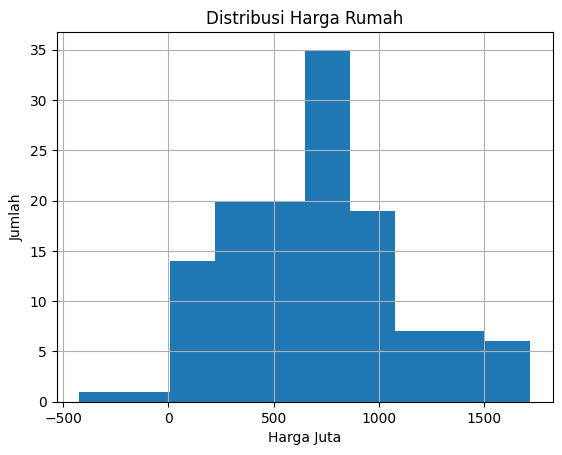


BOXPLOT


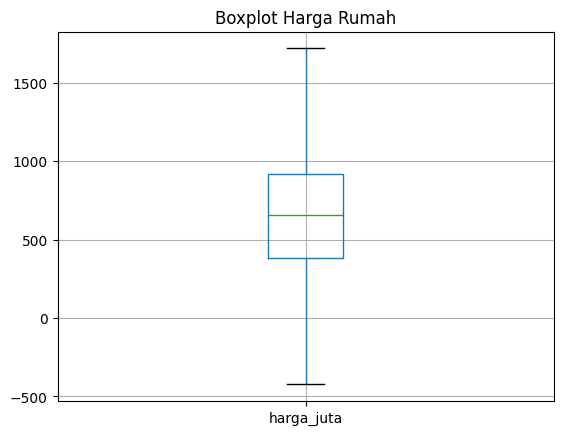


RATA-RATA HARGA PER KOTA
kota
Bandung        679.453125
Bdg            522.000000
Depok          813.700000
Dpk            545.500000
Jakarta       1128.557692
Jogja          802.250000
Makassar       483.444444
Mdn            575.000000
Medan          570.513889
Mksr           451.000000
Sby            869.500000
Semarang       790.777778
Smg            439.000000
Surabaya      1032.500000
Ygy            175.666667
Yogyakarta     423.142857
Name: harga_juta, dtype: float64

KORELASI
                    id   luas_m2  harga_juta     kamar  tahun_bangun
id            1.000000  0.094782    0.126360 -0.105930     -0.051174
luas_m2       0.094782  1.000000    0.678508 -0.048607      0.143642
harga_juta    0.126360  0.678508    1.000000 -0.080156      0.194361
kamar        -0.105930 -0.048607   -0.080156  1.000000      0.069356
tahun_bangun -0.051174  0.143642    0.194361  0.069356      1.000000

HEATMAP


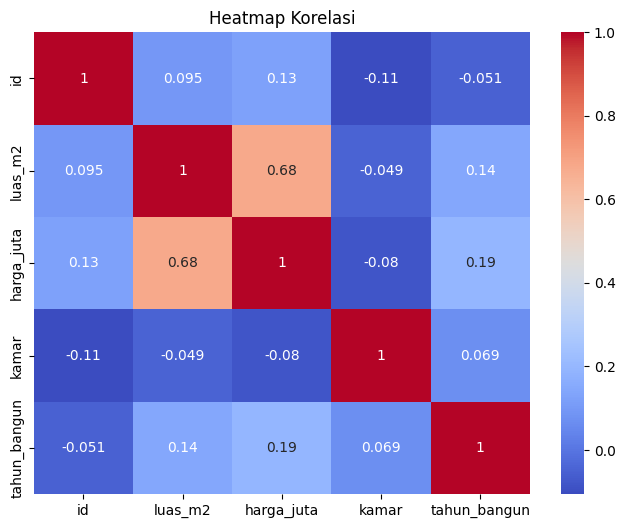


KESIMPULAN

1. Dataset berhasil dibersihkan
2. Missing value berhasil diimputasi
3. Data duplikat berhasil dihapus
4. Outlier berhasil ditangani menggunakan IQR
5. Dataset siap digunakan untuk analisis data
6. Visualisasi dan korelasi berhasil dibuat



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


SEMUA PROSES SELESAI


In [28]:
# =========================================================
# FULL DATA CLEANING + VISUALIZATION + ANALYSIS
# =========================================================

# =========================
# IMPORT LIBRARY
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv("housing_dirty.csv")

print("=" * 60)
print("DATASET BERHASIL DIBACA")
print("=" * 60)

print("\n5 DATA AWAL")
print(df.head())

# =========================================================
# INFO DATASET
# =========================================================

print("\n" + "=" * 60)
print("INFO DATASET")
print("=" * 60)

print(df.info())

print("\nSTATISTIK DATA")
print(df.describe())

# =========================================================
# CEK MISSING VALUE
# =========================================================

print("\n" + "=" * 60)
print("MISSING VALUE")
print("=" * 60)

print(df.isnull().sum())

# =========================================================
# CEK DUPLIKAT
# =========================================================

print("\n" + "=" * 60)
print("DUPLIKAT")
print("=" * 60)

print("Jumlah duplikat:", df.duplicated().sum())

# =========================================================
# HAPUS DUPLIKAT
# =========================================================

df.drop_duplicates(inplace=True)

# =========================================================
# NORMALISASI STRING
# =========================================================

print("\n" + "=" * 60)
print("NORMALISASI STRING")
print("=" * 60)

df['kota'] = (
    df['kota']
    .astype(str)
    .str.strip()
    .str.title()
)

df['kondisi'] = (
    df['kondisi']
    .astype(str)
    .str.strip()
    .str.lower()
)

print("\nData kota unik:")
print(df['kota'].unique())

print("\nData kondisi unik:")
print(df['kondisi'].unique())

# =========================================================
# IMPUTASI MISSING VALUE
# =========================================================

print("\n" + "=" * 60)
print("IMPUTASI MISSING VALUE")
print("=" * 60)

# Median numerik
df['luas_m2'] = df['luas_m2'].fillna(
    df['luas_m2'].median()
)

df['harga_juta'] = df['harga_juta'].fillna(
    df['harga_juta'].median()
)

# Modus kategorik
df['kamar'] = df['kamar'].fillna(
    df['kamar'].mode()[0]
)

print("\nSisa missing value:")
print(df.isnull().sum())

# =========================================================
# HANDLE OUTLIER DENGAN IQR
# =========================================================

print("\n" + "=" * 60)
print("HANDLE OUTLIER")
print("=" * 60)

target_cols = [
    'harga_juta',
    'luas_m2',
    'tahun_bangun'
]

for col in target_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"\nKolom: {col}")
    print(f"Batas bawah: {lower}")
    print(f"Batas atas : {upper}")

    # Winsorization / clipping
    df[col] = df[col].clip(lower, upper)

print("\nOutlier berhasil ditangani")

# =========================================================
# VALIDASI AKHIR
# =========================================================

print("\n" + "=" * 60)
print("VALIDASI DATA")
print("=" * 60)

print("\nTotal Missing:")
print(df.isnull().sum().sum())

print("\nTotal Duplikat:")
print(df.duplicated().sum())

print("\nShape Akhir:")
print(df.shape)

# =========================================================
# SIMPAN DATA CLEAN
# =========================================================

df.to_csv(
    "housing_clean.csv",
    index=False
)

print("\nDataset bersih berhasil disimpan!")
print("Nama file: housing_clean.csv")

# =========================================================
# VISUALISASI HISTOGRAM
# =========================================================

print("\n" + "=" * 60)
print("VISUALISASI HISTOGRAM")
print("=" * 60)

df['harga_juta'].hist()

plt.title("Distribusi Harga Rumah")
plt.xlabel("Harga Juta")
plt.ylabel("Jumlah")

plt.show()

# =========================================================
# BOXPLOT OUTLIER
# =========================================================

print("\n" + "=" * 60)
print("BOXPLOT")
print("=" * 60)

df.boxplot(column=['harga_juta'])

plt.title("Boxplot Harga Rumah")

plt.show()

# =========================================================
# RATA-RATA HARGA PER KOTA
# =========================================================

print("\n" + "=" * 60)
print("RATA-RATA HARGA PER KOTA")
print("=" * 60)

mean_kota = df.groupby(
    'kota'
)['harga_juta'].mean()

print(mean_kota)

# =========================================================
# KORELASI
# =========================================================

print("\n" + "=" * 60)
print("KORELASI")
print("=" * 60)

corr = df.corr(numeric_only=True)

print(corr)

# =========================================================
# HEATMAP KORELASI
# =========================================================

print("\n" + "=" * 60)
print("HEATMAP")
print("=" * 60)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Heatmap Korelasi")

plt.show()

# =========================================================
# KESIMPULAN
# =========================================================

print("\n" + "=" * 60)
print("KESIMPULAN")
print("=" * 60)

print("""
1. Dataset berhasil dibersihkan
2. Missing value berhasil diimputasi
3. Data duplikat berhasil dihapus
4. Outlier berhasil ditangani menggunakan IQR
5. Dataset siap digunakan untuk analisis data
6. Visualisasi dan korelasi berhasil dibuat
""")

# =========================================================
# DOWNLOAD FILE (GOOGLE COLAB)
# =========================================================

try:

    from google.colab import files

    files.download("housing_clean.csv")

except:

    print("\nBukan Google Colab, download otomatis dilewati")

# =========================================================
# SELESAI
# =========================================================

print("\n" + "=" * 60)
print("SEMUA PROSES SELESAI")
print("=" * 60)

In [22]:
df.groupby('kota')['harga_juta'].mean()

,harga_juta
kota,
Bandung,679.453125
Bdg,522.000000
Depok,813.700000
Dpk,545.500000
Jakarta,1128.557692
Jogja,802.250000
Makassar,483.444444
Mdn,575.000000
Medan,570.513889


In [23]:

df = pd.read_csv("housing_clean.csv")

df.head()

,id,luas_m2,harga_juta,kota,kamar,tahun_bangun,kondisi
0,1.0,297.0,1084.0,Jogja,2.0,2000.0,baik
1,2.0,254.0,761.0,Medan,4.0,1995.0,bagus
2,3.0,249.7,895.0,Depok,4.0,1983.0,baik
3,4.0,49.7,178.0,Ygy,5.0,2013.0,baik
4,5.0,133.4,424.0,Medan,5.0,2004.0,sedang


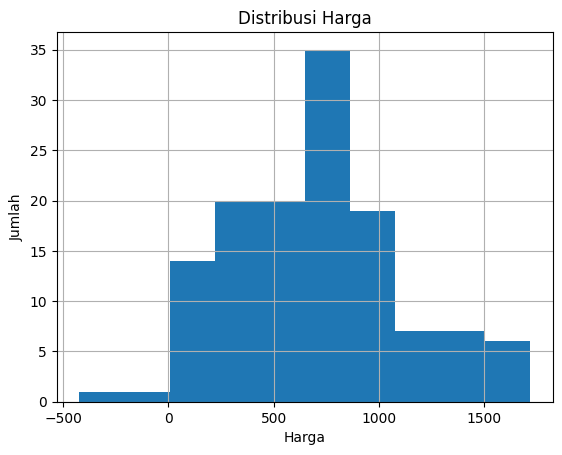

In [24]:
import matplotlib.pyplot as plt

# Histogram harga
df['harga_juta'].hist()

plt.title("Distribusi Harga")
plt.xlabel("Harga")
plt.ylabel("Jumlah")

plt.show()

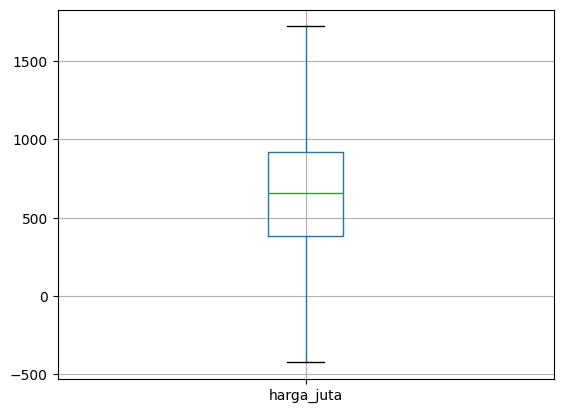

In [25]:
df.boxplot(column=['harga_juta'])

plt.show()

In [26]:
print(df.corr(numeric_only=True))

                    id   luas_m2  harga_juta     kamar  tahun_bangun
id            1.000000  0.094782    0.126360 -0.124467     -0.051174
luas_m2       0.094782  1.000000    0.678508 -0.000334      0.143642
harga_juta    0.126360  0.678508    1.000000 -0.085956      0.194361
kamar        -0.124467 -0.000334   -0.085956  1.000000      0.002137
tahun_bangun -0.051174  0.143642    0.194361  0.002137      1.000000


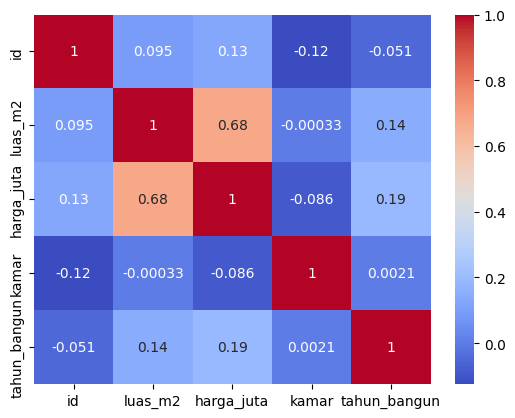

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()